In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

In [2]:
BASE_DIR = "Drowsy_dataset"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")

IMG_SIZE = 224
BATCH_SIZE = 32

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.4, 1.6],   # handles poor lighting
    horizontal_flip=True
)

In [4]:
test_datagen = ImageDataGenerator(rescale=1./255)

In [5]:
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


Found 5859 images belonging to 2 classes.
Found 1483 images belonging to 2 classes.


In [6]:
print(train_gen.class_indices)

{'DROWSY': 0, 'NATURAL': 1}


In [6]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weights = dict(enumerate(class_weights))

In [7]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

In [8]:
base_model.trainable = False  # Freeze base first

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_drowsy_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)


In [10]:
history = model.fit(
    train_gen,
    epochs=10,
    validation_data=test_gen,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr, checkpoint]
)


Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4838 - loss: 0.8913
Epoch 1: val_accuracy improved from None to 0.79299, saving model to best_drowsy_model.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 281s 1s/step - accuracy: 0.5119 - loss: 0.8485 - val_accuracy: 0.7930 - val_loss: 0.5620 - learning_rate: 1.0000e-04
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5533 - loss: 0.7628
Epoch 2: val_accuracy improved from 0.79299 to 0.87323, saving model to best_drowsy_model.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 271s 1s/step - accuracy: 0.5692 - loss: 0.7461 - val_accuracy: 0.8732 - val_loss: 0.4752 - learning_rate: 1.0000e-04
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6117 - loss: 0.6928
Epoch 3: val_accuracy improved from 0.87323 to 0.88469, saving model to best_drowsy_model.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 266s 1s/step - accuracy: 0.6310 - loss: 0.6751 - val_accuracy: 0.8847 - val_loss: 0.4249 - learning_rate: 1.0000e-04
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6613 - loss: 0.6229
Epoch 4: val_accuracy improved from 0.88469 to 0.90290, saving model to best_drowsy_model.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - accuracy: 0.6711 - loss: 0.6127 - val_accuracy: 0.9029 - val_loss: 0.3829 - learning_rate: 1.0000e-04
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7034 - loss: 0.5846
Epoch 5: val_accuracy improved from 0.90290 to 0.91571, saving model to best_drowsy_model.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - accuracy: 0.6947 - loss: 0.5881 - val_accuracy: 0.9157 - val_loss: 0.3539 - learning_rate: 1.0000e-04
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7030 - loss: 0.5699
Epoch 6: val_accuracy improved from 0.91571 to 0.92515, saving model to best_drowsy_model.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.7088 - loss: 0.5656 - val_accuracy: 0.9252 - val_loss: 0.3272 - learning_rate: 1.0000e-04
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7069 - loss: 0.5575
Epoch 7: val_accuracy improved from 0.92515 to 0.93392, saving model to best_drowsy_model.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.7226 - loss: 0.5390 - val_accuracy: 0.9339 - val_loss: 0.3081 - learning_rate: 1.0000e-04
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7437 - loss: 0.5144
Epoch 8: val_accuracy did not improve from 0.93392
184/184 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.7484 - loss: 0.5101 - val_accuracy: 0.9305 - val_loss: 0.2956 - learning_rate: 1.0000e-04
Epoch 9/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7697 - loss: 0.4903
Epoch 9: val_accuracy improved from 0.93392 to 0.93459, saving model to best_drowsy_model.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step - accuracy: 0.7679 - loss: 0.4893 - val_accuracy: 0.9346 - val_loss: 0.2815 - learning_rate: 1.0000e-04
Epoch 10/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7574 - loss: 0.4913
Epoch 10: val_accuracy did not improve from 0.93459
184/184 ━━━━━━━━━━━━━━━━━━━━ 240s 1s/step - accuracy: 0.7648 - loss: 0.4849 - val_accuracy: 0.9346 - val_loss: 0.2689 - learning_rate: 1.0000e-04


In [11]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_gen,
    epochs=10,
    validation_data=test_gen,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 274s 1s/step - accuracy: 0.7073 - loss: 0.5909 - val_accuracy: 0.9238 - val_loss: 0.2563 - learning_rate: 1.0000e-05
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 316s 1s/step - accuracy: 0.8372 - loss: 0.3661 - val_accuracy: 0.9474 - val_loss: 0.1870 - learning_rate: 1.0000e-05
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 249s 1s/step - accuracy: 0.8691 - loss: 0.2924 - val_accuracy: 0.9595 - val_loss: 0.1529 - learning_rate: 1.0000e-05
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 290s 2s/step - accuracy: 0.8892 - loss: 0.2518 - val_accuracy: 0.9548 - val_loss: 0.1434 - learning_rate: 1.0000e-05
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 320s 1s/step - accuracy: 0.9008 - loss: 0.2339 - val_accuracy: 0.9481 - val_loss: 0.1423 - learning_rate: 1.0000e-05
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 313s 1s/step - accuracy: 0.9072 - loss: 0.2143 - val_accuracy: 0.9670 - val_loss: 0.0917 - learning_rate: 1.0000e-05
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 354s 2s/step - acc

In [12]:
model.save("final_drowsy_model.h5")

In [13]:
print("\nTest Accuracy:")
test_loss, test_acc = model.evaluate(test_gen)
print(f"Accuracy: {test_acc:.4f}")


Test Accuracy:
47/47 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9690 - loss: 0.0786
Accuracy: 0.9690


47/47 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step


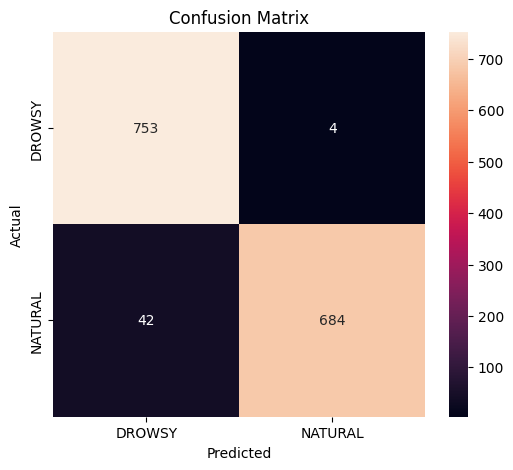

In [14]:
test_gen.reset()
pred_probs = model.predict(test_gen)
pred_classes = (pred_probs > 0.5).astype(int).ravel()

cm = confusion_matrix(test_gen.classes, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

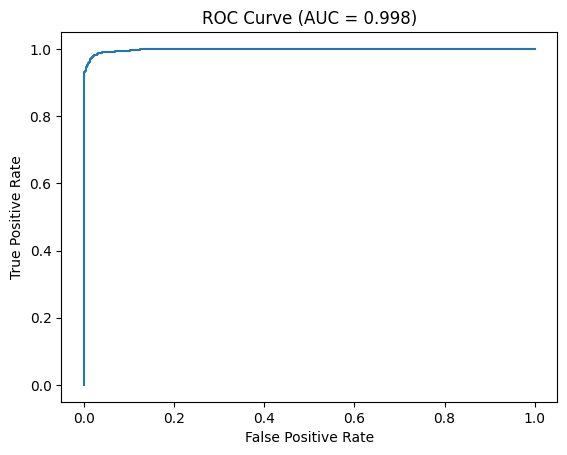

In [15]:
fpr, tpr, _ = roc_curve(test_gen.classes, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [16]:
print("\nClassification Report:")
print(classification_report(test_gen.classes, pred_classes, target_names=test_gen.class_indices.keys()))


Classification Report:
              precision    recall  f1-score   support

      DROWSY       0.95      0.99      0.97       757
     NATURAL       0.99      0.94      0.97       726

    accuracy                           0.97      1483
   macro avg       0.97      0.97      0.97      1483
weighted avg       0.97      0.97      0.97      1483

